<h1 align="center">
<h1 align="center"> Recommendation System using AI/HCI Project


<h3 align="center"> Trey Williams

<h3 align="center"> University of the Cumberlands

<h3 align="center"> MSAI-631-A01: Artificial Intelligence for Human-Computer Interaction
    
<h3 align="center"> Dr. Alan Dennis

In [2]:
import pandas as pd
import numpy as np
import os

In [22]:
# File Import

from google.colab import files

uploaded = files.upload()

Saving onet_career_master.csv to onet_career_master.csv


In [24]:
#Check Dataset

career_master_df = pd.read_csv(
    "/content/onet_career_master.csv"
)

print("Master dataset loaded successfully.")
print("Shape:", career_master_df.shape)

career_master_df.head()

Master dataset loaded successfully.
Shape: (1016, 12)


,O*NET-SOC Code,Title,Description,Skills,Knowledge,Abilities,Work Styles,Education,Education Response Percent,Experience,Experience Response Percent,combined_text
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,"Critical Thinking, Speaking, Reading Comprehen...","Administration and Management, Personnel and H...","Oral Comprehension, Oral Expression, Written C...","Leadership Orientation, Dependability, Integri...",Master's Degree,45.91,Over 10 years,68.24,Career: Chief Executives. Description: Determi...
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh...","Writing, Critical Thinking, Reading Comprehens...","English Language, Administration and Managemen...","Written Expression, Oral Comprehension, Writte...",NaN,Master's Degree,74.07,"Over 4 years, up to and including 6 years",40.74,Career: Chief Sustainability Officers. Descrip...
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ...","Reading Comprehension, Active Listening, Speak...","Administration and Management, Customer and Pe...","Oral Comprehension, Written Comprehension, Ora...","Leadership Orientation, Dependability, Integri...",High School Diploma or the equivalent (such as...,28.76,"Over 4 years, up to and including 6 years",24.23,Career: General and Operations Managers. Descr...
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes...",NaN,NaN,NaN,"Leadership Orientation, Integrity, Dependabili...",NaN,NaN,NaN,NaN,"Career: Legislators. Description: Develop, int..."
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici...","Active Listening, Speaking, Critical Thinking,...","Sales and Marketing, English Language, Communi...","Oral Expression, Oral Comprehension, Written C...","Leadership Orientation, Innovation, Social Ori...",Bachelor's Degree,72.87,"Over 2 years, up to and including 4 years",37.57,Career: Advertising and Promotions Managers. D...


In [25]:
# CHECK MISSING VALUES

missing_summary = (
    career_master_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

print(missing_summary)

Experience                     383
Work Styles                    125
Education                      115
Education Response Percent     115
Experience Response Percent    115
Abilities                      106
Knowledge                      106
Skills                         106
Description                      0
Title                            0
O*NET-SOC Code                   0
combined_text                    0
dtype: int64


In [26]:
# CLEAN TEXT FIELDS

text_columns = [
    "Title",
    "Description",
    "Skills",
    "Knowledge",
    "Abilities",
    "Work Styles",
    "Education",
    "Experience"
]

for col in text_columns:
    career_master_df[col] = (
        career_master_df[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

In [27]:
# CREATE COMBINED CAREER TEXT

career_master_df["combined_text"] = (
    "Career: " + career_master_df["Title"] + ". "
    + "Description: " + career_master_df["Description"] + ". "
    + "Skills: " + career_master_df["Skills"] + ". "
    + "Knowledge: " + career_master_df["Knowledge"] + ". "
    + "Abilities: " + career_master_df["Abilities"] + ". "
    + "Work Styles: " + career_master_df["Work Styles"] + ". "
    + "Education: " + career_master_df["Education"] + ". "
    + "Experience: " + career_master_df["Experience"] + "."
)

In [28]:
# INSPECT ONE COMPLETE CAREER PROFILE

example = career_master_df.iloc[0]

print("CAREER:", example["Title"])
print()
print(example["combined_text"])

CAREER: Chief Executives

Career: Chief Executives. Description: Determine and formulate policies and provide overall direction of companies or private and public sector organizations within guidelines set up by a board of directors or similar governing body. Plan, direct, or coordinate operational activities at the highest level of management with the help of subordinate executives and staff managers.. Skills: Critical Thinking, Speaking, Reading Comprehension, Writing, Active Listening, Monitoring, Active Learning, Mathematics, Learning Strategies, Science. Knowledge: Administration and Management, Personnel and Human Resources, English Language, Customer and Personal Service, Economics and Accounting, Public Safety and Security, Computers and Electronics, Sales and Marketing, Mathematics, Education and Training, Law and Government, Psychology, Engineering and Technology, Communications and Media, Sociology and Anthropology, Production and Processing, Geography, Telecommunications, A

In [30]:
# TRAIN TF-IDF CAREER RECOMMENDATION MODEL

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib

# Build TF-IDF model
tfidf_model = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=10000
)

# Train on the combined O*NET career descriptions
career_matrix = tfidf_model.fit_transform(
    career_master_df["combined_text"]
)

print("Model trained successfully.")
print("Number of careers:", career_matrix.shape[0])
print("Number of TF-IDF features:", career_matrix.shape[1])

# Save the model
joblib.dump(
    tfidf_model,
    "/content/career_tfidf_model.pkl"
)

joblib.dump(
    career_matrix,
    "/content/career_tfidf_matrix.pkl"
)

print("\nModel saved.")

Model trained successfully.
Number of careers: 1016
Number of TF-IDF features: 10000

Model saved.


TOP 5 CAREER RECOMMENDATIONS


,O*NET-SOC Code,Title,Description,Education,Experience,Similarity Score
0,27-3099.00,"Media and Communication Workers, All Other",All media and communication workers not listed...,,,0.223063
1,27-4099.00,"Media and Communication Equipment Workers, All...",All media and communication equipment workers ...,,,0.200077
2,15-1211.01,Health Informatics Specialists,Apply knowledge of nursing and informatics to ...,Master's Degree,"Over 2 years, up to and including 4 years",0.135666
3,29-9021.00,Health Information Technologists and Medical R...,Apply knowledge of healthcare and information ...,,,0.124778
4,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,Master's Degree,Over 10 years,0.115307


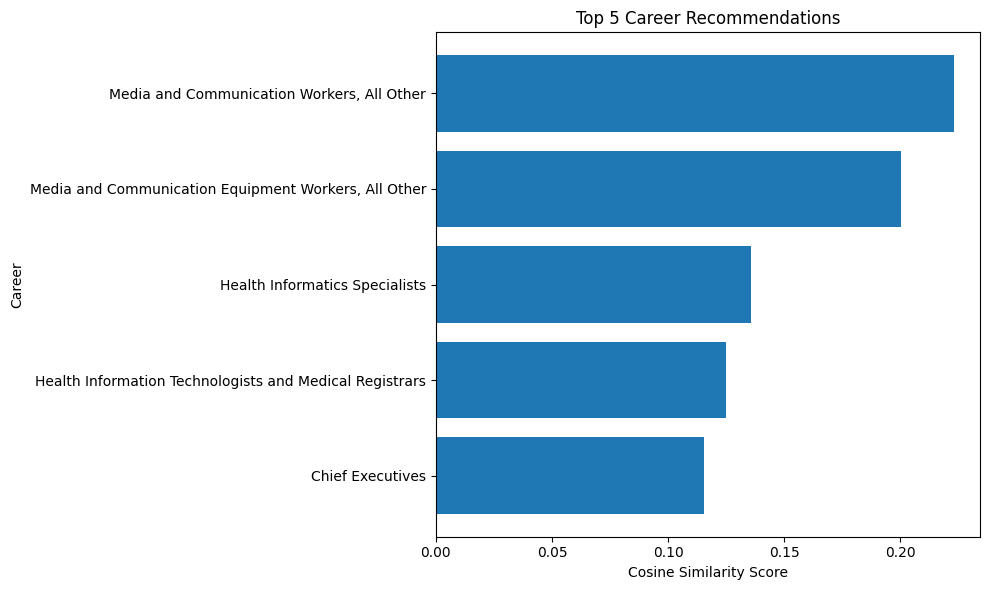

In [31]:
# TEST MODEL AND DISPLAY TOP 5 RECOMMENDATIONS

import matplotlib.pyplot as plt

# Test user profile
test_user = """
Education: Master's Degree.
Skills: leadership, critical thinking, communication,
problem solving, mathematics, planning, management,
training, and decision making.
Knowledge: administration, management, education,
technology, business, and personnel management.
Abilities: oral communication, written communication,
reasoning, analysis, and problem solving.
Work styles: leadership, initiative, responsibility,
achievement, and adaptability.
Experience: more than 10 years of professional
and management experience.
"""

# Convert user profile into TF-IDF representation
user_vector = tfidf_model.transform([test_user])

# Calculate similarity between user and every career
similarity_scores = cosine_similarity(
    user_vector,
    career_matrix
).flatten()

# Add scores to a temporary results dataframe
results_df = career_master_df[
    [
        "O*NET-SOC Code",
        "Title",
        "Description",
        "Education",
        "Experience"
    ]
].copy()

results_df["Similarity Score"] = similarity_scores

# Get top 5 recommendations
top_5 = (
    results_df
    .sort_values(
        "Similarity Score",
        ascending=False
    )
    .head(5)
    .reset_index(drop=True)
)

print("TOP 5 CAREER RECOMMENDATIONS")
print("=" * 60)

display(top_5)

# ------------------------------------------------------------
# CHART
# ------------------------------------------------------------

chart_data = top_5.sort_values(
    "Similarity Score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart_data["Title"],
    chart_data["Similarity Score"]
)

plt.xlabel("Cosine Similarity Score")
plt.ylabel("Career")
plt.title("Top 5 Career Recommendations")

plt.tight_layout()
plt.show()

In [32]:
# BUILD MINILM CAREER RECOMMENDATION MODEL

!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
import numpy as np

# Load pretrained MiniLM model
minilm_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

# Create embeddings for every O*NET career profile
career_embeddings = minilm_model.encode(
    career_master_df["combined_text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

print("MiniLM embeddings created successfully.")
print("Number of careers:", career_embeddings.shape[0])
print("Embedding dimensions:", career_embeddings.shape[1])

# Save career embeddings
np.save(
    "/content/career_minilm_embeddings.npy",
    career_embeddings
)

# Save the MiniLM model locally
minilm_model.save(
    "/content/career_minilm_model"
)

print("\nMiniLM model and embeddings saved.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

MiniLM embeddings created successfully.
Number of careers: 1016
Embedding dimensions: 384


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


MiniLM model and embeddings saved.


TOP 5 MINILM CAREER RECOMMENDATIONS


,O*NET-SOC Code,Title,Description,Education,Experience,Similarity Score
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,Master's Degree,Over 10 years,0.746982
1,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ...",High School Diploma or the equivalent (such as...,"Over 4 years, up to and including 6 years",0.741160
2,11-3012.00,Administrative Services Managers,"Plan, direct, or coordinate one or more admini...",High School Diploma or the equivalent (such as...,"Over 2 years, up to and including 4 years",0.705550
3,11-9199.00,"Managers, All Other",All managers not listed separately.,,,0.703435
4,13-1151.00,Training and Development Specialists,Design or conduct work-related training and de...,Bachelor's Degree,"Over 2 years, up to and including 4 years",0.697516


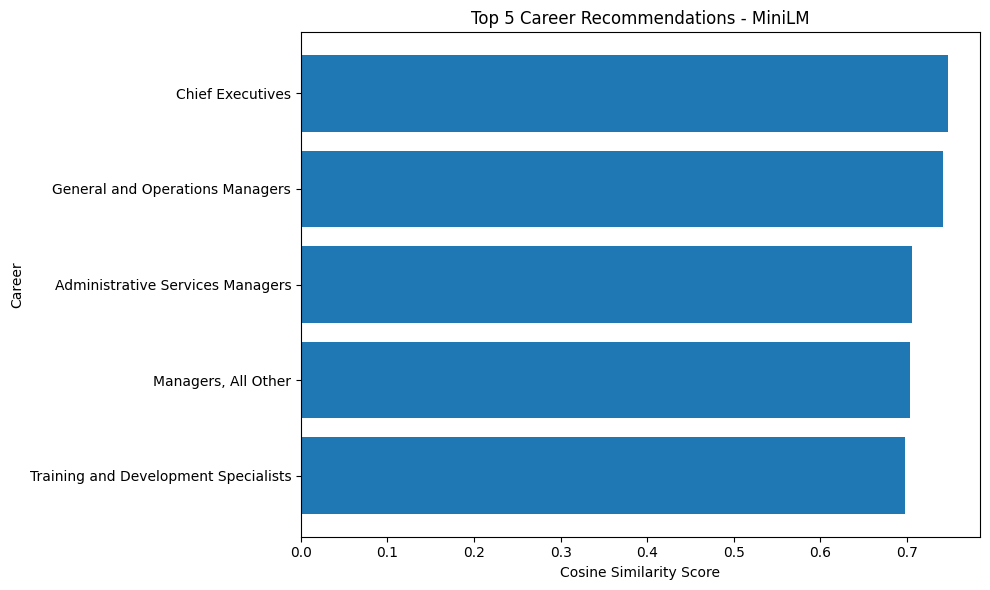

In [34]:
# TEST MINILM MODEL

import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Same test user used for TF-IDF
test_user = """
Education: Master's Degree.
Skills: leadership, critical thinking, communication,
problem solving, mathematics, planning, management,
training, and decision making.
Knowledge: administration, management, education,
technology, business, and personnel management.
Abilities: oral communication, written communication,
reasoning, analysis, and problem solving.
Work styles: leadership, initiative, responsibility,
achievement, and adaptability.
Experience: more than 10 years of professional
and management experience.
"""

# Convert user profile into MiniLM embedding
user_embedding = minilm_model.encode(
    [test_user],
    normalize_embeddings=True
)

# Compare user against all careers
minilm_scores = cosine_similarity(
    user_embedding,
    career_embeddings
).flatten()

# Build results
minilm_results_df = career_master_df[
    [
        "O*NET-SOC Code",
        "Title",
        "Description",
        "Education",
        "Experience"
    ]
].copy()

minilm_results_df["Similarity Score"] = minilm_scores

# Top 5 recommendations
minilm_top_5 = (
    minilm_results_df
    .sort_values(
        "Similarity Score",
        ascending=False
    )
    .head(5)
    .reset_index(drop=True)
)

print("TOP 5 MINILM CAREER RECOMMENDATIONS")
print("=" * 60)

display(minilm_top_5)

# ------------------------------------------------------------
# CHART
# ------------------------------------------------------------

chart_data = minilm_top_5.sort_values(
    "Similarity Score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart_data["Title"],
    chart_data["Similarity Score"]
)

plt.xlabel("Cosine Similarity Score")
plt.ylabel("Career")
plt.title("Top 5 Career Recommendations - MiniLM")

plt.tight_layout()
plt.show()

# Career Recommendation Model - Next Steps

## Current Status

The recommendation portion of the project is complete.

The project now includes two recommendation approaches:

1. **TF-IDF + Cosine Similarity**
   - Serves as the baseline model.
   - Matches the user's profile to O*NET careers based mainly on shared words and phrases.

2. **Sentence Transformers `all-MiniLM-L6-v2` + Cosine Similarity**
   - Serves as the primary recommendation model.
   - Uses semantic embeddings to compare the meaning of the user's profile with the O*NET career profiles.

During testing, MiniLM produced recommendations that were more consistent with the overall meaning of the test user's background. The TF-IDF model is still useful as a baseline for comparison.

The final system should use **MiniLM as the default recommendation model** and keep TF-IDF available as the baseline.

---

## Model Files

The project currently uses the following files:

```text
onet_career_master.csv
career_tfidf_model.pkl
career_tfidf_matrix.pkl
career_minilm_embeddings.npy
career_minilm_model/

## Application Function Contract

The user interface should call one recommendation function:

```python
recommend_careers()
```

The recommended function signature is:

```python
def recommend_careers(user_profile, model_type="minilm", top_n=5):
```

### Expected Input

The function should receive a single text string containing the user's profile information.

Example:

```python
user_profile = """
Education: Master's Degree.
Skills: leadership, communication, critical thinking, planning.
Interests: technology, education, management.
Experience: more than 10 years of professional experience.
Career goals: leadership, management, training, and technology.
"""
```

The interface should combine the user's form responses into this single profile string before sending it to the recommendation function.

The expected inputs are:

```text
user_profile: str
model_type: str = "minilm"
top_n: int = 5
```

The default model should be:

```python
model_type="minilm"
```

The TF-IDF baseline can also be called with:

```python
model_type="tfidf"
```

### Expected Output

The function should return a Pandas DataFrame containing the top career recommendations.

The expected columns are:

```text
O*NET-SOC Code
Title
Description
Education
Experience
Similarity Score
```

Example call:

```python
results = recommend_careers(
    user_profile,
    model_type="minilm",
    top_n=5
)
```

### Application Flow

```text
Gradio Form
    ↓
Combine User Responses
    ↓
Create user_profile String
    ↓
recommend_careers(
    user_profile,
    model_type="minilm",
    top_n=5
)
    ↓
Pandas DataFrame
    ↓
Display Top 5 Career Recommendations
```

The MiniLM model should be used as the primary recommendation model, while TF-IDF should remain available as the baseline comparison model.